### data generation


In [1]:
import pandas as pd
import numpy as np

def generate_big_data_telemetry(samples=1000000):
    np.random.seed(42)
    print(f"Generating {samples} records... stay put.")
    
    data = {
        'level': np.random.randint(1, 100, samples),
        'session_min': np.random.uniform(1, 60, samples),
        'fails_10': np.random.randint(0, 25, samples),
        'think_time_sec': np.random.uniform(1, 20, samples),
        'skill': np.random.uniform(0.1, 1.0, samples)
    }
    
    df = pd.DataFrame(data)
    
    # Logic: High Fails + Low Skill + Short Sessions = High Churn
    churn_score = (df['fails_10'] * 0.8) - (df['skill'] * 10) + (40 / df['session_min'])
    # Adding 'Noise' to make it realistic (AI shouldn't be 100% perfect)
    churn_score += np.random.normal(0, 5, samples)
    
    # Target: 15% Churn Rate
    df['churn'] = (churn_score > np.percentile(churn_score, 85)).astype(int)
    
    return df

df = generate_big_data_telemetry()
df.to_csv('p1_big_data_1m.csv', index=False)
print("SUCCESS: 1 Million records saved to 'p1_big_data_1m.csv'")

Generating 1000000 records... stay put.
SUCCESS: 1 Million records saved to 'p1_big_data_1m.csv'


In [4]:
import pandas as pd

# Load the big dataset
df = pd.read_csv('p1_big_data_1m.csv')

print("--- DATASET OVERVIEW ---")
print(df.info()) # Shows memory usage and column types

print("\n--- CHURN DISTRIBUTION ---")
print(df['churn'].value_counts()) # Shows how many '0' vs '1'

--- DATASET OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   level           1000000 non-null  int64  
 1   session_min     1000000 non-null  float64
 2   fails_10        1000000 non-null  int64  
 3   think_time_sec  1000000 non-null  float64
 4   skill           1000000 non-null  float64
 5   churn           1000000 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 45.8 MB
None

--- CHURN DISTRIBUTION ---
churn
0    850000
1    150000
Name: count, dtype: int64


### PHASE 2: DATA VISUALIZATION


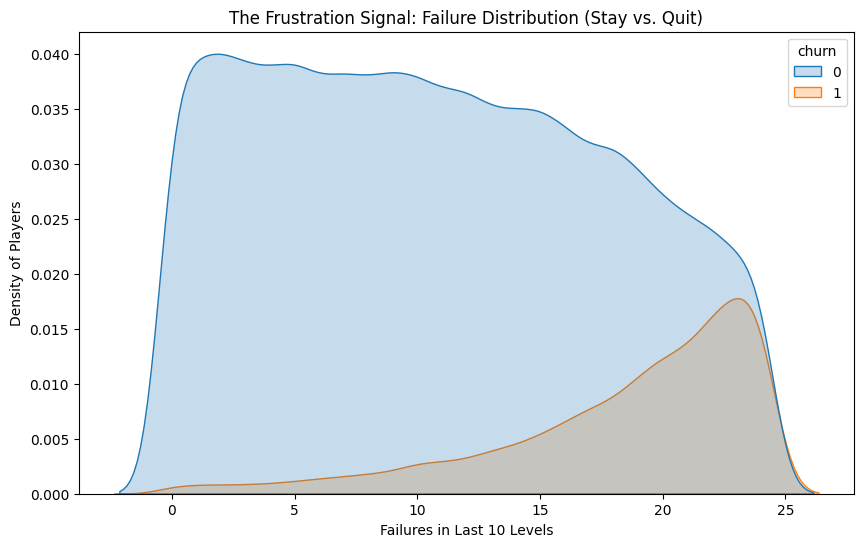

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take a small sample so the graph loads fast
sample_df = df.sample(100000)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=sample_df, x='fails_10', hue='churn', fill=True)
plt.title('The Frustration Signal: Failure Distribution (Stay vs. Quit)')
plt.xlabel('Failures in Last 10 Levels')
plt.ylabel('Density of Players')
plt.show()

### PHASE 3: PRE-PROCESSING & SCALING


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the data
df = pd.read_csv('p1_big_data_1m.csv')

# 2. Separate Features (Input) from Target (Output)
X = df.drop(['churn'], axis=1) # Everything except the 'churn' column
y = df['churn']               # Only the 'churn' column

# 3. Split: 80% to train the AI, 20% to test it later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale: Turn all numbers into a 'Standard' range (Mean=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("PHASE 3 SUCCESSFUL.")
print(f"Rows for Training: {X_train.shape[0]}")
print(f"Rows for Testing: {X_test.shape[0]}")

PHASE 3 SUCCESSFUL.
Rows for Training: 800000
Rows for Testing: 200000


### PHASE 4 — THE NEURAL NETWORK ARCHITECTURE


In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. RELOAD & PREP (Fixes the NameError)
df = pd.read_csv('p1_big_data_1m.csv')
X = df.drop(['churn'], axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. ARCHITECTURE
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid') 
])

# 3. COMPILE
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. TRAIN
print("Training on 10 Lakh Rows... Starting now.")
history = model.fit(
    X_train, y_train, 
    epochs=5,           
    batch_size=1024,    
    validation_split=0.1, 
    verbose=1
)

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training on 10 Lakh Rows... Starting now.
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8481 - loss: 0.3414 - val_accuracy: 0.8803 - val_loss: 0.2699
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8869 - loss: 0.2558 - val_accuracy: 0.8904 - val_loss: 0.2494
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8927 - loss: 0.2442 - val_accuracy: 0.8943 - val_loss: 0.2425
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8949 - loss: 0.2394 - val_accuracy: 0.8952 - val_loss: 0.2391
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8963 - loss: 0.2367 - val_accuracy: 0.8966 - val_loss: 0.2370


### PHASE 5: EVALUATION (THE FINAL TEST)


In [3]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Ask the brain to predict the 200,000 test players
predictions = (model.predict(X_test) > 0.5).astype("int32")

# 2. Print the final report
print("--- FINAL EVALUATION REPORT ---")
print(classification_report(y_test, predictions))

# 3. Save the model for your portfolio
model.save('jephin_dda_model_v1.h5')
print("\nSUCCESS: Model saved as 'jephin_dda_model_v1.h5'")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 6s 944us/step


--- FINAL EVALUATION REPORT ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.94    170152
           1       0.72      0.50      0.59     29848

    accuracy                           0.90    200000
   macro avg       0.82      0.73      0.77    200000
weighted avg       0.89      0.90      0.89    200000


SUCCESS: Model saved as 'jephin_dda_model_v1.h5'
